In [1]:
import warnings
import numpy as np
import scipy as sp
%matplotlib inline
import matplotlib.pyplot as plt
import tanglepack
import tanglepack.InitialManifold
%load_ext autoreload
%autoreload 2

/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


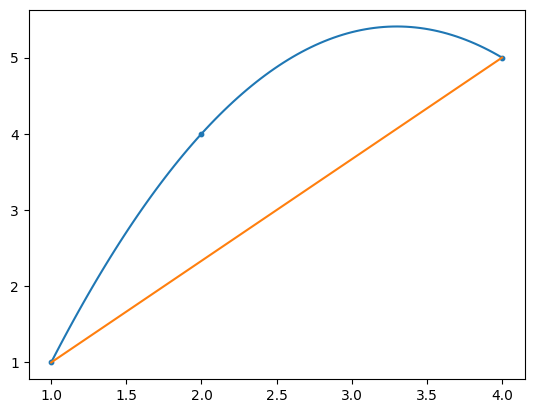

In [3]:
points = np.array([[1, 1], [2, 4], [4, 5]])

x_vals = np.linspace(points[0, 0], points[-1, 0], 100)

line = tanglepack.Manifold.linear_fit(points)

parabola = tanglepack.Manifold.parabolic_fit(points)

plt.figure()
plt.scatter(points[:, 0], points[:, 1], s=10)
plt.plot(x_vals, parabola(x_vals))
plt.plot(x_vals, line(x_vals))
plt.show()

In [3]:
points = np.array([[0, 1], [1, 1], [1, 2], [2, 2]])

print(points[1:3])

[[1 1]
 [1 2]]


In [58]:
print(np.linspace(0, 1, 5))

[0.   0.25 0.5  0.75 1.  ]


In [4]:
matrix = np.array([[1, 2], [3, 4]])
eigenvalues, eigenvectors = np.linalg.eig(matrix)

print(f'eigenvalues: {eigenvalues}')
print(f'eigenvectors: {eigenvectors}')

eigenvalues: [-0.37228132  5.37228132]
eigenvectors: [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [69]:
eigenvector = [[np.ones((2, 1)), np.ones((2, 1))] for i in range(3)]


In [70]:
eigenvector[1][1]

array([[1.],
       [1.]])

In [ ]:
initial_guess = np.array([0.6, 0.2])

period, _ = np.shape(np.atleast_2d(initial_guess))

print(period)


1


In [76]:
for i in range(1):
    print('wow')

wow


In [98]:
def henon(point):
    """defines the henon map for classical parameters to test basic functionality"""

    a, b = (1.4, 0.3)

    x = point[0]
    y = point[1]

    return np.array([a + x ** 2 + b * y, x])


def henon_inverse(point):
    """defines the inverse henon map for classical parameters"""

    a, b = (1.4, 0.3)

    x = point[0]
    y = point[1]

    return np.array([y, (x - y ** 2 - a) / b])

def henon_jacobian(point):
    """defines the jacobian for the henon map"""

    a, b = (1.4, 0.3)

    x = point[0]
    y = point[1]

    return np.array([[2*x, b], [1, 0]])
    

In [2]:
def henon(point):
    """defines the henon map for classical parameters to test basic functionality"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([y - k + x ** 2, -b * x])


def henon_inverse(point):
    """defines the inverse henon map for classical parameters"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y ** 2) / (b ** 2)])


def henon_jacobian(point):
    """defines the jacobian for the henon map"""

    b, k = (1, 10)

    x = point[0]
    y = point[1]

    return np.array([[2*x, 1], [-b, 0]])
    

In [4]:
test_point = [1, 1]
print(test_point)
mapped = np.array(henon(test_point))
print(mapped)
backwards = np.array(henon_inverse(mapped))
print(backwards)
print(backwards - test_point)

[1, 1]
[-8 -1]
[1. 1.]
[0. 0.]


In [65]:
arr = np.array([[3, 4], [6, 8]])

print(np.linalg.norm(arr, axis=1))

print(np.average(np.linalg.norm(arr, axis=1)))

[ 5. 10.]
7.5


In [3]:
tolerance = 1e-8

guess = np.array([4, -4])
# guess = np.array([[0.6, 0.2], [0.6, 0.2]])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse)

fixed_point = point.fixed_point

print(f"fixed point: {type(fixed_point)}")

difference = point.accuracy

print(f"accuracy: {difference}")

point.compute_eigenvectors()

print(f'eigens {point.eigenvectors}')
print(point.eigenvectors[0][0])


This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
fixed point: <class 'numpy.ndarray'>
accuracy: 0.011184341740278863
entered eigenvalues
eigens [[array([ 0.99317577, -0.11662714]), array([-0.11662714,  0.99317577])]]
[ 0.99317577 -0.11662714]


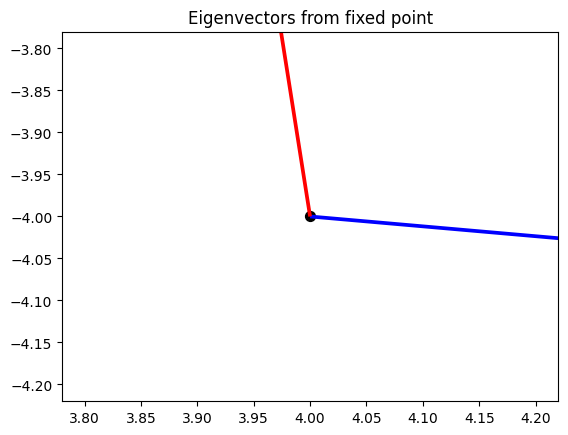

In [4]:
plt.figure()
plt.scatter(guess[0], guess[1], s=50, color='k')
plt.quiver(guess[0], guess[1], point.eigenvectors[0][0][0], point.eigenvectors[0][0][1], angles='xy', scale_units='xy', scale=.1, color='b')
plt.quiver(guess[0], guess[1], point.eigenvectors[0][1][0], point.eigenvectors[0][1][1], angles='xy', scale_units='xy', scale=.1, color='r')
plt.title("Eigenvectors from fixed point")
# plt.ylim([-1, .3])
# plt.xlim([-1, 0])
plt.show()

In [25]:
warnings.simplefilter("ignore", np.polynomial.polyutils.RankWarning)

# guess = np.array([0.6, 0.2])
guess = np.array([4, -4])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

manifold = tanglepack.InitialManifold.InitialManifold(point)

first_point = manifold.get_first_point()

print(f' accuracy {manifold.fixed_point.accuracy}')

first_preiterate = manifold.get_first_point_preiterate()

manifold.get_initial_fundamental_segment()

while len(manifold.points.points) < 150:
    manifold.map_fundamental_segment()

# for i in range(10):
#     manifold.map_fundamental_segment()

# for i in range(len(manifold.points)):
    # print(f'woah: {manifold.points.points[i]}')

# iterate forwards and backwards to see what we get

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
entered eigenvalues
eigen [ 0.99317577 -0.11662714]
 accuracy 0.011184341740278863
eigen [ 0.99317577 -0.11662714]
eigen [ 0.99317577 -0.11662714]
first point: [ 4.3277326  -4.31792758]
eigen [ 0.99317577 -0.11662714]
first pre_iterate: [ 4.31792758 -4.31676597]
number of points: 6
---------
inner trigger: 0
area estimate: -9.513901117715685e-18
inner trigger: 1
area estimate: 1.4083511946173167e-07
inner trigger: 2
area estimate: 4.575064085629277e-08
inner trigger: 3
area estimate: 1.5777218104420236e-30
number of points: 12
---------
inner trigger: 0
area estimate: -9.513901117715685e-18
inner trigger: 1
area estimate: 1.4083511946173167e-07
inner trigger: 2
area estimate: 4.575064085629277e-08
inner trigger: 3
area estimate: -7.379372724495377e-11
inner trigger: 4
area estimate: -3.146825567574631e-08
inner trigger: 5
area es

/mnt/c/Users/etccu/Documents/TanglePack/src/tanglepack/Manifold.py:218: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  area, _ = spi.quad(difference, x_min, x_max)


inner trigger: 61
area estimate: 0.016594372108722253
Refining manifold...
inner trigger: 62
area estimate: -0.002026268691428469
inner trigger: 63
area estimate: 0.01659457332814381
Refining manifold...
inner trigger: 64
area estimate: -0.0020262461734678727
inner trigger: 65
area estimate: 0.016595547491696002
Refining manifold...
number of points: 78
---------
inner trigger: 0
area estimate: -9.513901117715685e-18
inner trigger: 1
area estimate: 1.4083511946173167e-07
inner trigger: 2
area estimate: 4.575064085629277e-08
inner trigger: 3
area estimate: -7.379372724495377e-11
inner trigger: 4
area estimate: -3.146825567574631e-08
inner trigger: 5
area estimate: -5.032437439532068e-18
inner trigger: 6
area estimate: 1.6273780456840943e-08
inner trigger: 7
area estimate: 0.00014287473276850627
inner trigger: 8
area estimate: 2.6329201792054746e-29
inner trigger: 9
area estimate: -0.00014306629641069673
inner trigger: 10
area estimate: -3.146825567574631e-08
inner trigger: 11
area estim

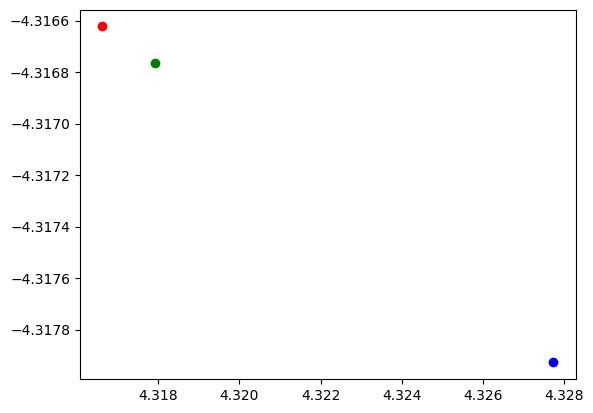

In [21]:
plt.figure()
plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='r')
plt.scatter(first_point[0], first_point[1], color='b')
plt.scatter(first_preiterate[0], first_preiterate[1], color='g')
# plt.xlim([-.88, -.886])
# plt.ylim([-.88, -.886])
plt.show()

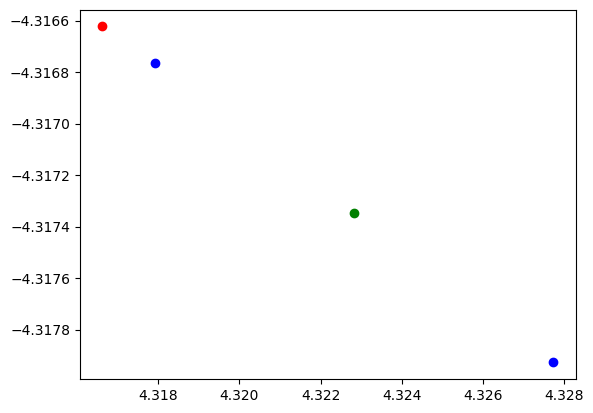

In [23]:
manifold.refine_two_points(np.array([first_point, first_preiterate]), 3)
middle_point = manifold.points.points[-1]

plt.figure()
plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='r')
plt.scatter(first_point[0], first_point[1], color='b')
plt.scatter(first_preiterate[0], first_preiterate[1], color='b')
plt.scatter(middle_point[0], middle_point[1], color='g')
# plt.xlim([-.88, -.886])
# plt.ylim([-.88, -.886])
plt.show()

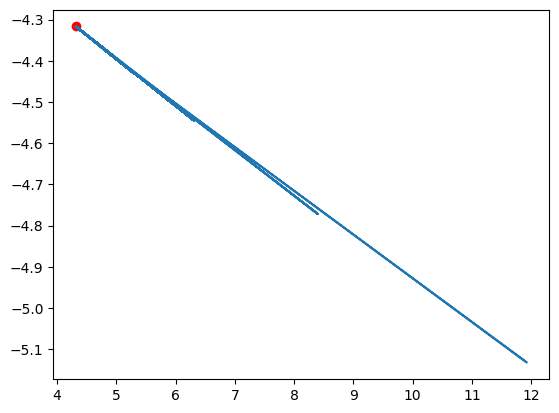

1018


In [26]:
plt.figure()
points = np.array(manifold.points.points)
plt.plot(points[:, 0], points[:, 1])
plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='r')
# plt.xlim([3, 7])
# plt.ylim([-5, -4])
plt.show()
print(len(points))

In [ ]:
warnings.simplefilter("ignore", np.polynomial.polyutils.RankWarning)

# guess = np.array([-0.6, -0.2])
guess = np.array([4, -4])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

# manifold = tanglepack.InitialManifold.InitialManifold(point)

print(point.eigenvectors)
print(point.eigenvalues)

point2 = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse)

# manifold = tanglepack.InitialManifold.InitialManifold(point2)s

print(point2.eigenvectors)
print(point2.eigenvalues)

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
entered eigenvalues
[[array([ 0.99317577, -0.11662714]), array([-0.11662714,  0.99317577])]]
[array([[8.51582066],
       [0.11742849]])]
This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
entered eigenvalues
[[array([ 0.99317577, -0.11662714]), array([-0.11662714,  0.99317577])]]
[array([[8.51582066],
       [0.11742849]])]


In [149]:
print(f"preiterate point: {henon_inverse(first_point)}")
print(f"built in preiterate: {first_preiterate}")

print(f"iterate: {henon(first_preiterate)}")
print(f"built iterate: {first_point}")

preiterate point: [ 4.31531878 -4.2942436 ]
built in preiterate: [ 4.31531878 -4.2942436 ]
iterate: [ 4.3277326  -4.31531878]
built iterate: [ 4.3277326  -4.31531878]


1.0


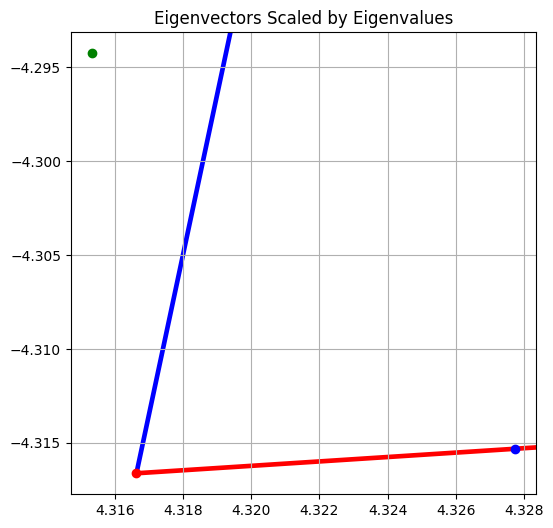

In [171]:
eigenvectors = point.eigenvectors
eigenvalues = point.eigenvalues

eigenvectors = np.squeeze(eigenvectors)  # Remove extra dimensions if necessary
eigenvalues = np.squeeze(eigenvalues)    # Same here

# Scale eigenvectors by their eigenvalues
scaled_vectors = eigenvectors * 5#eigenvalues[:, np.newaxis]  # Multiply each vector by its corresponding eigenvalue

# Define origins for vectors
X = np.zeros(scaled_vectors.shape[0])  # x-coordinates of vector origins
Y = np.zeros(scaled_vectors.shape[0])  # y-coordinates of vector origins

X = point.fixed_point[0][0] * np.ones(scaled_vectors.shape[0])
Y = point.fixed_point[0][1] * np.ones(scaled_vectors.shape[0])

# Extract components
U = scaled_vectors[:, 0]  # X-components of scaled vectors
V = scaled_vectors[:, 1]  # Y-components of scaled vectors

print(np.dot(eigenvalues[0], eigenvalues[1]))

# Plot
plt.figure(figsize=(6,6))
# fig, ax = plt.subplots(figsize=(6,6))
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color=['r', 'b'], width=0.01)

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='r')
plt.scatter(first_point[0], first_point[1], color='b')
plt.scatter(first_preiterate[0], first_preiterate[1], color='g')

# plt.xlim(-.9, -.87)
# plt.ylim(-.9, -.88)
# plt.xlim(-.884, -.884 + 2e-4)
# plt.ylim(-.884, -.884 + 2e-4)


# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.title("Eigenvectors Scaled by Eigenvalues")
plt.show()

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
[ 0.99317577 -0.11662714]


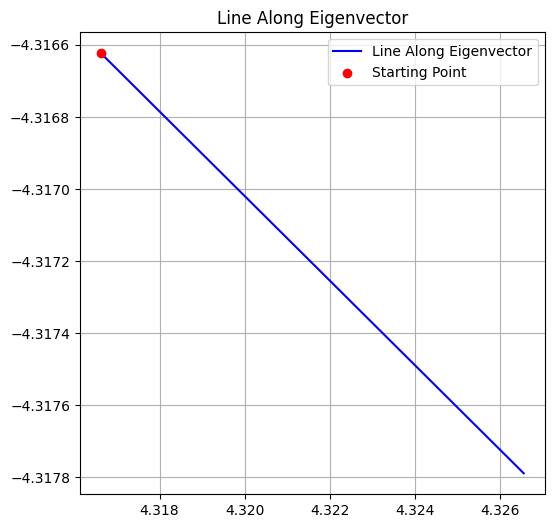

In [18]:
# guess = np.array([0.6, 0.2])
guess = np.array([4, -4])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

manifold = tanglepack.InitialManifold.InitialManifold(point)

eigenvector = point.eigenvectors[0][0]
print(eigenvector)

t_values = np.linspace(0, 1e-2, 100)

line = np.array([point.fixed_point[0] + t * eigenvector for t in t_values])

X, Y = line[:, 0], line[:, 1]

# Plot
plt.figure(figsize=(6,6))
plt.plot(X, Y, 'b-', label="Line Along Eigenvector")  # Line
plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='red', zorder=3, label="Starting Point")  # Mark the start point
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()

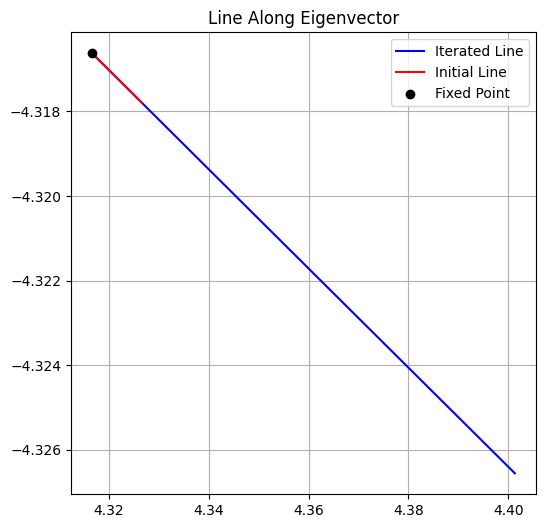

In [24]:
# iterated_line = np.array(henon(line))
iterated_line = np.array(list(map(henon, line)))

X, Y = iterated_line[:, 0], iterated_line[:, 1]

# Plot
plt.figure(figsize=(6,6))
plt.plot(X, Y, 'b-', label="Iterated Line")  # Line

X, Y = line[:, 0], line[:, 1]
plt.plot(X, Y, 'r-', label="Initial Line")  # Line

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='black', zorder=3, label="Fixed Point")  # Mark the start point
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()

In [184]:
test = np.array([4.31662458, -4.31662318])
henon(test)

array([ 4.31662458, -4.31662458])

In [186]:
point.jacobian @ point.eigenvectors[0][0]

array([8.45770675, 0.99317577])

2.0627317362681365e-15


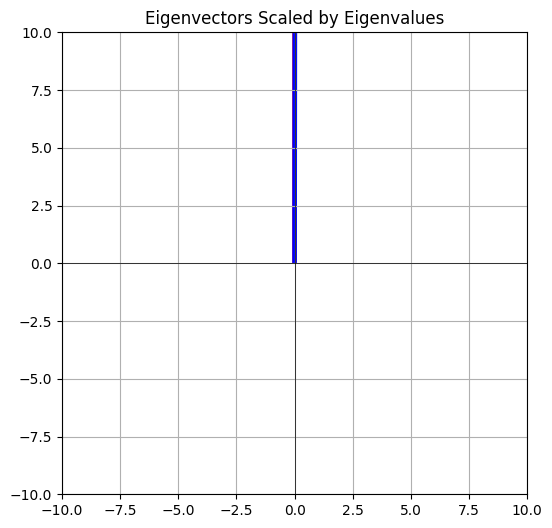

In [20]:
eigenvectors = point2.eigenvectors
eigenvalues = point2.eigenvalues

eigenvectors = np.squeeze(eigenvectors)  # Remove extra dimensions if necessary
eigenvalues = np.squeeze(eigenvalues)    # Same here

# Scale eigenvectors by their eigenvalues
scaled_vectors = eigenvectors * 1e19#eigenvalues[:, np.newaxis]  # Multiply each vector by its corresponding eigenvalue

# Define origins for vectors
X = np.zeros(scaled_vectors.shape[0])  # x-coordinates of vector origins
Y = np.zeros(scaled_vectors.shape[0])  # y-coordinates of vector origins

# Extract components
U = scaled_vectors[:, 0]  # X-components of scaled vectors
V = scaled_vectors[:, 1]  # Y-components of scaled vectors

print(np.dot(eigenvalues[0], eigenvalues[1]))

# Plot
plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color=['r', 'b'], width=0.01)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.title("Eigenvectors Scaled by Eigenvalues")
plt.show()

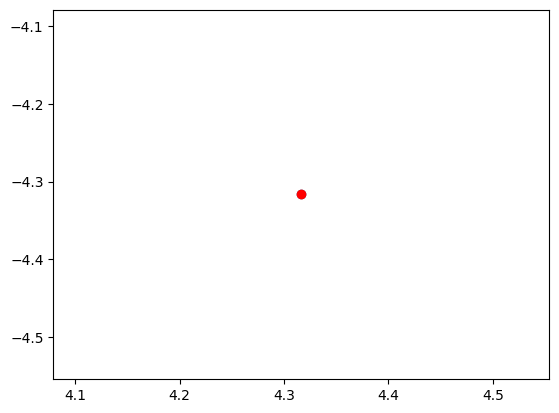